Published on March 11, 2026. By Prata, Marília (mpwolke)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

#Two lines Required to Plot Plotly
import plotly.io as pio
pio.renderers.default = 'iframe'

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/birdclef-2026/sample_submission.csv
/kaggle/input/competitions/birdclef-2026/taxonomy.csv
/kaggle/input/competitions/birdclef-2026/train_soundscapes_labels.csv
/kaggle/input/competitions/birdclef-2026/train.csv
/kaggle/input/competitions/birdclef-2026/recording_location.txt
/kaggle/input/competitions/birdclef-2026/train_audio/rufgna3/XC252355.ogg
/kaggle/input/competitions/birdclef-2026/train_audio/rufgna3/XC550621.ogg
/kaggle/input/competitions/birdclef-2026/train_audio/rufgna3/XC172127.ogg
/kaggle/input/competitions/birdclef-2026/train_audio/rufgna3/XC499706.ogg
/kaggle/input/competitions/birdclef-2026/train_audio/rufgna3/XC331429.ogg
/kaggle/input/competitions/birdclef-2026/train_audio/rufgna3/XC417588.ogg
/kaggle/input/competitions/birdclef-2026/train_audio/rufgna3/XC80419.ogg
/kaggle/input/competitions/birdclef-2026/train_audio/rufgna3/XC330455.ogg
/kaggle/input/competitions/birdclef-2026/train_audio/rufgna3/XC344738.ogg
/kaggle/input/competitions/birdcl

## Competition Citation:

@misc{birdclef-2026,

    author = {Stefan Kahl and Tom Denton and Larissa Sugai and Liliana Piatti and Ryan Holbrook and Holger Klinck and Ashley Oldacre},
    
    title = {BirdCLEF+ 2026},
    year = {2026},
    
    howpublished = {\url{https://kaggle.com/competitions/birdclef-2026}},
    note = {Kaggle}
}

![](https://www.imageclef.org/system/files/BirdBrazilMini.jpg)ImageCLEF

## BirdCLEF+ 2026

Acoustic Species Identification in the Pantanal, South America

"The goal of this competition is to develop machine learning frameworks capable of identifying understudied species within continuous audio data from Brazil's Pantanal wetlands. Successful solutions will help advance biodiversity monitoring in the last wild places on Earth."

https://www.kaggle.com/competitions/birdclef-2026/overview

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.offline as py
import plotly.express as px

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
#By Paulo Junqueira https://www.kaggle.com/code/paulojunqueira/pew-pew-overview-birdclef-2023/notebook

import re
import librosa
import librosa.display

import IPython.display as ipd
from urllib.request import urlopen
from datetime import datetime, timedelta

import plotly.graph_objects as go
from scipy.interpolate import interp1d 
from bs4 import BeautifulSoup as bs
import librosa
import librosa.display
import IPython.display as ipd
# import noisereduce as nr

from tqdm.notebook import tqdm
# Pytorch
import torch
import torchaudio
import requests
from PIL import Image

## train csv

In [4]:
meta = pd.read_csv('../input/competitions/birdclef-2026/train.csv')
meta['secondary_labels'] = meta['secondary_labels'].apply(lambda x: re.findall(r"'(\w+)'", x))
meta['len_sec_labels'] = meta['secondary_labels'].map(len)
meta.head(2)

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,len_sec_labels
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,0
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,0


### Vocalizations: Geographic location - Brazil's Pantanal wetlands.

"This competition involves building models that automatically identify wildlife species from their vocalizations in audio recordings collected across the Pantanal wetlands. This work will support more reliable biodiversity monitoring in one of the world’s most diverse and threatened ecosystems."

"Understanding how ecological communities respond to environmental change and restoration efforts is a central challenge in conservation science. The Pantanal — a wetland spanning 150,000+ km² across Brazil and neighboring countries — is home to over 650 bird species plus countless other animals, yet much of it remains unmonitored. Seasonal flooding, wildfires, agricultural expansion, and climate change make regular fieldwork challenging."

https://www.kaggle.com/competitions/birdclef-2026/overview

In [5]:
# http://www.gutenberg.org/cache/epub/730/pg730.txt
rec_location = open("../input/competitions/birdclef-2026/recording_location.txt", "r").read()
print (rec_location[:2000])

Pantanal, Mato Grosso do Sul, Brazil, South America

More info: https://en.wikipedia.org/wiki/Pantanal

Coordinates of recorder deployment sites:

Latitude: -16.5 to -21.6
Longitude: -55.9 to -57.6


In [6]:
#By Paulo Junqueira https://www.kaggle.com/code/paulojunqueira/pew-pew-overview-birdclef-2023/notebook

#Two lines Required to Plot Plotly
import plotly.io as pio
pio.renderers.default = 'iframe'


df_plot = meta.groupby(['primary_label','latitude', 'longitude']).count().reset_index()[['primary_label','scientific_name','latitude', 'longitude']].rename(columns = {'scientific_name':'count'})
meta_2 = meta.merge(df_plot, on = ['primary_label','latitude', 'longitude'], how = 'left').dropna(subset = ['count'])
meta_2['count'] = meta_2['count'].astype('int')

values_list = meta_2['count'].values.tolist()

interpolation = interp1d([1, max(values_list)], [3,20])
radius = interpolation(values_list)
fig = go.Figure(go.Densitymapbox(lat =meta_2['latitude'],lon = meta_2['longitude'], radius = radius,z = meta_2['count']))

fig.update_layout(mapbox_style="open-street-map",height = 800,
                  mapbox = {
                          'center': {'lat': 0, 
                          'lon': 0},
                      'zoom':0
                  })
fig.show()

### Geographic Distribution

"latitude & longitude: Coordinates for where the recording was taken. Some bird species may have local call 'dialects,' so you may want to seek geographic diversity in your training data."

https://www.kaggle.com/competitions/birdclef-2026/data

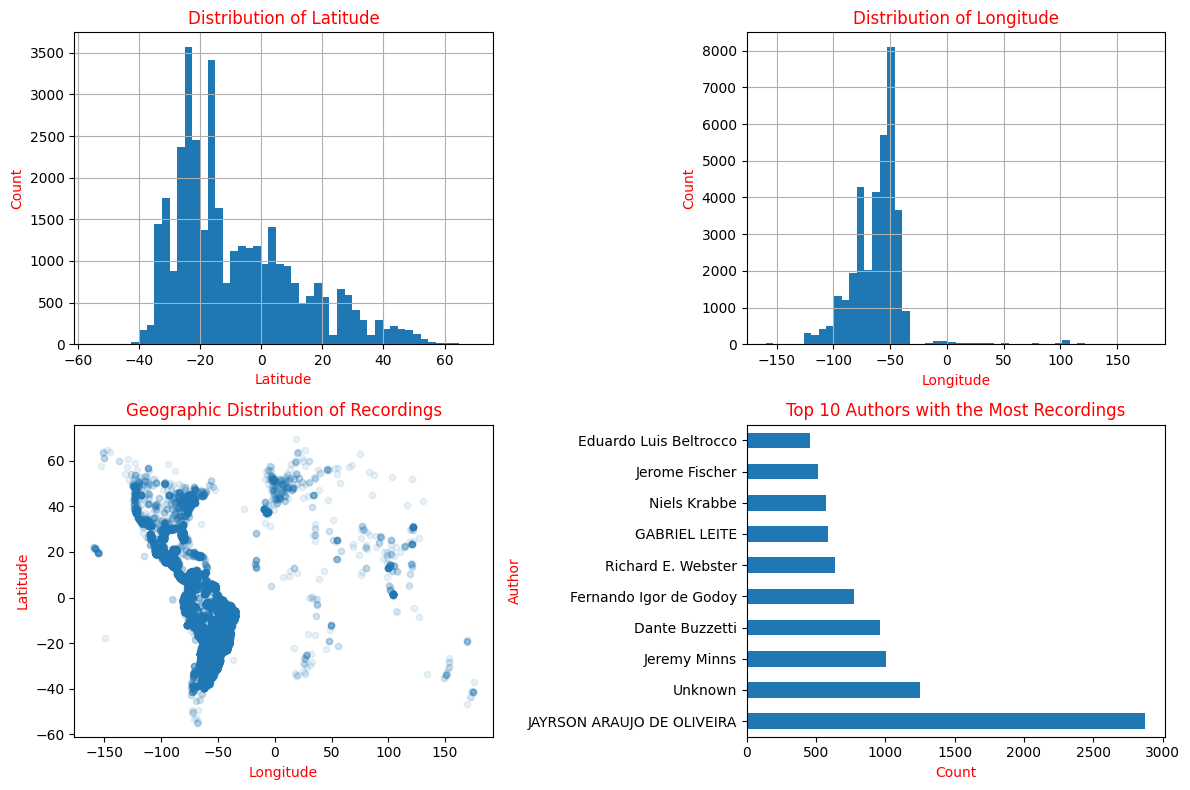

In [7]:
#By Ben Jenkins https://www.kaggle.com/code/benjenkins96/identify-eastern-african-bird-species-by-sound

# Set up a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plot a histogram of the latitude values
meta['latitude'].hist(bins=50, ax=axs[0, 0])
axs[0, 0].set_title('Distribution of Latitude', color='red')
axs[0, 0].set_xlabel('Latitude', color='red')
axs[0, 0].set_ylabel('Count', color='red')
# Plot a histogram of the longitude values
meta['longitude'].hist(bins=50, ax=axs[0, 1])
axs[0, 1].set_title('Distribution of Longitude', color='red')
axs[0, 1].set_xlabel('Longitude', color='red')
axs[0, 1].set_ylabel('Count', color='red')

# Plot a scatterplot of the latitude and longitude values
meta.plot.scatter(x='longitude', y='latitude', alpha=0.1, ax=axs[1, 0])
axs[1, 0].set_title('Geographic Distribution of Recordings', color='red')
axs[1, 0].set_xlabel('Longitude', color='red')
axs[1, 0].set_ylabel('Latitude', color='red')

# Print the top 10 authors with the most recordings
meta['author'].value_counts().nlargest(10).plot.barh(ax=axs[1, 1])
axs[1, 1].set_title('Top 10 Authors with the Most Recordings', color='red')
axs[1, 1].set_xlabel('Count', color='red')
axs[1, 1].set_ylabel('Author', color='red')

# Adjust the layout of the subplots
plt.tight_layout()

## Taxonomy csv file

"taxonomy.csv - Data on the different species, including iNaturalist taxon ID and class name (Aves, Amphibia, Mammalia, Insecta, Reptilia). Most insect species in this competition have not been identified on species level and instead occur as sonotypes (e.g., 47158son16 as insect sonotype 16); these sonotypes are treated as classes despite the lack of species ID and some of them also occur in the test data. The 234 rows of this file represent the 234 class columns in the submission file. primary_label specifies the submission file column name."

https://www.kaggle.com/competitions/birdclef-2026/data

In [8]:
taxonomy = pd.read_csv("/kaggle/input/competitions/birdclef-2026/taxonomy.csv")
pd.set_option('display.max_columns', None)
taxonomy.head()

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


### Brazil's Pantanal wetlands by Animals Class Names

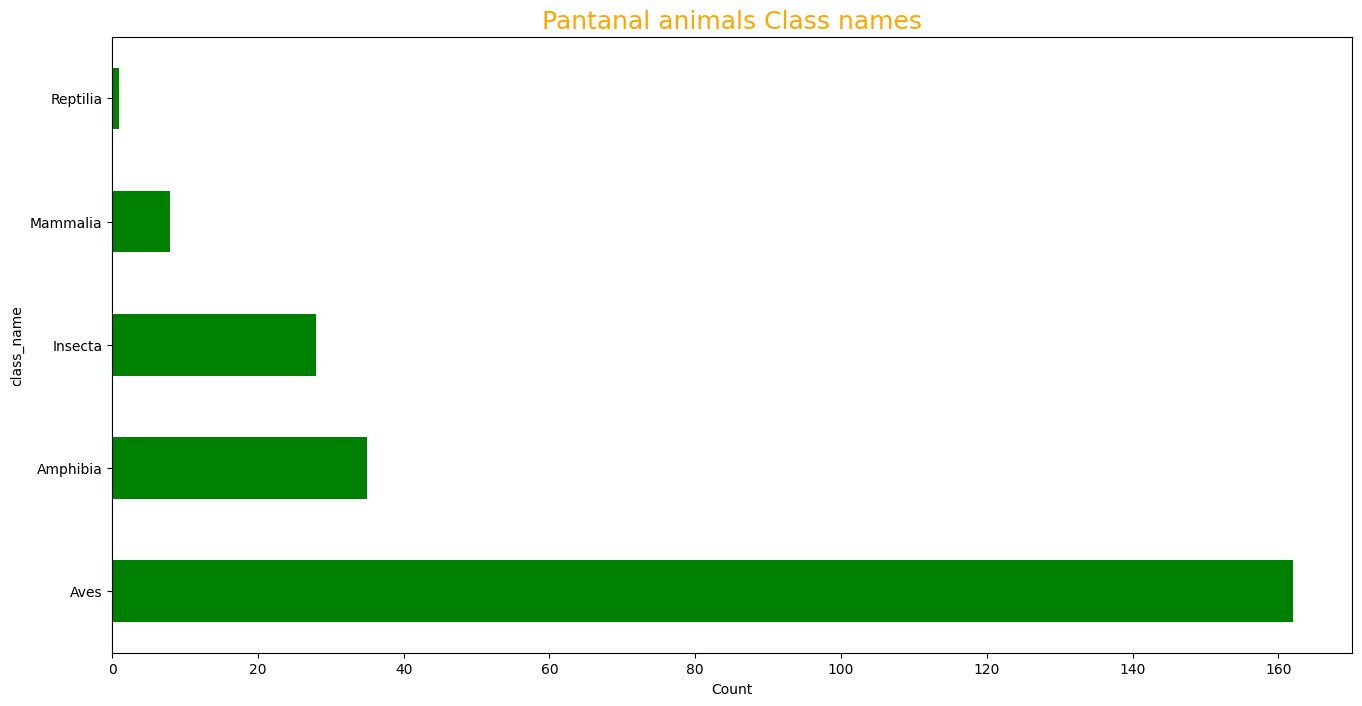

In [9]:
ax = taxonomy['class_name'].value_counts()[:20].plot.barh(figsize=(16, 8), color='green')
ax.set_title('Pantanal animals Class names', size=18, color='orange')
ax.set_ylabel('class_name', size=10)
ax.set_xlabel('Count', size=10);

## Groupby Pantanal animals by Scientific name and Class names

In [10]:
taxonomy.groupby(['scientific_name','class_name']).size().reset_index(name='count')

,scientific_name,class_name,count
0,Accipiter striatus,Aves,1
1,Adenomera guarani,Amphibia,1
2,Alouatta caraya,Mammalia,1
3,Amazona aestiva,Aves,1
4,Amazona amazonica,Aves,1
...,...,...,...
229,Turdus rufiventris,Aves,1
230,Tyrannus melancholicus,Aves,1
231,Tyrannus savana,Aves,1
232,Tyto furcata,Aves,1


### Pantanal wetlands Animals by Class names

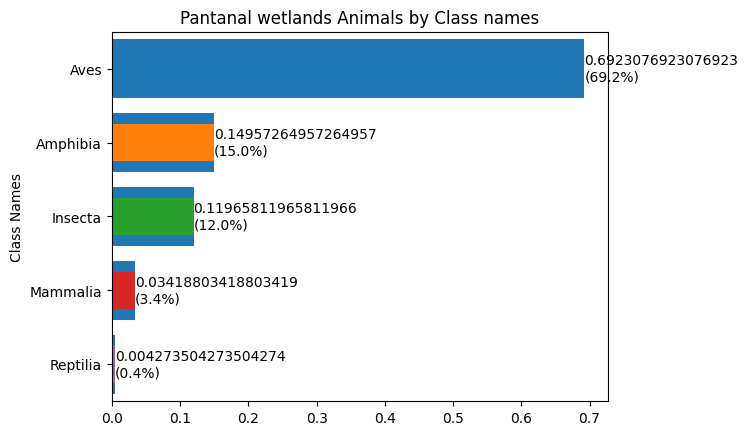

In [11]:
#Eunji Goo https://www.kaggle.com/code/quantum09/is-it-going-to-rain

class_proportion = taxonomy['class_name'].value_counts()/taxonomy['class_name'].value_counts().sum()
colormap = plt.cm.tab10(range(0, len(class_proportion)))
labels = class_proportion.index
values = class_proportion.values

bars = plt.barh(labels, values)

#plt.xlabel("Frequency") #Não alterou nada

#plt.legend(title='Forest Animals Class names' , bbox_to_anchor=(1.0, 1), loc='lower right')#HORRÌVEL!

bar_plot = class_proportion.plot.barh(color=colormap)

# Add titles, labels, invert y-axis

bar_plot.set_title("Pantanal wetlands Animals by Class names")
bar_plot.set_ylabel("Class Names")

total = values.sum()
for bar, count in zip(bars, values):
    width = bar.get_width()
    pct = count / total * 100
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f"{count}\n({pct:.1f}%)",
             ha='left', va='center')

#Invert the axis to have the descending order
bar_plot.invert_yaxis()
plt.show(bar_plot)

## Display ogg Soundscapes

"Important note: Some species with occurrences in the hidden test data might only have train samples in the labeled portion of train_soundscapes and not in the train_audio (XC and iNat data). However, not all species from train_soundscapes have occurrences in the test_soundscapes."

https://www.kaggle.com/competitions/birdclef-2026/data

In [12]:
# Code source: Brian McFee
# License: ISC

##################
# Standard imports
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import librosa

import librosa.display

## Librosa

In [13]:
# Code source: Brian McFee
# License: ISC

y, sr = librosa.load('../input/competitions/birdclef-2026/train_audio/rufgna3/XC252355.ogg', duration=120)


# And compute the spectrogram magnitude and phase
S_full, phase = librosa.magphase(librosa.stft(y))

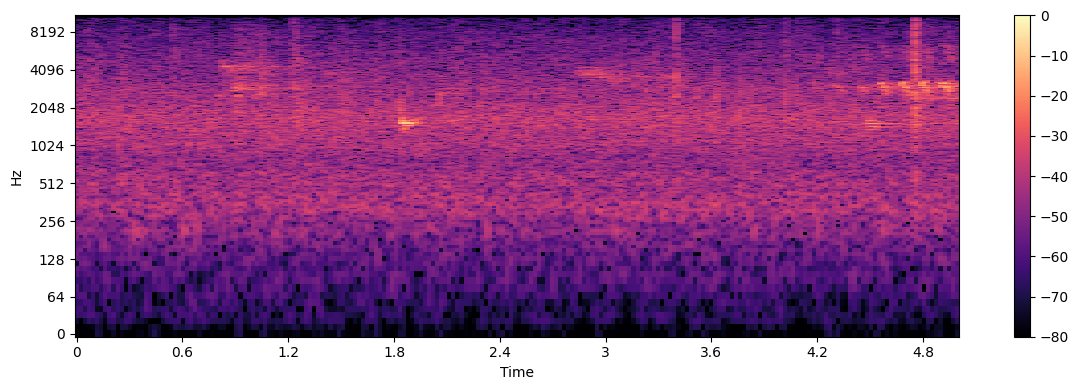

In [14]:
# Code source: Brian McFee
# License: ISC

idx = slice(*librosa.time_to_frames([30, 35], sr=sr))
plt.figure(figsize=(12, 4))
librosa.display.specshow(librosa.amplitude_to_db(S_full[:, idx], ref=np.max),
                         y_axis='log', x_axis='time', sr=sr)
plt.colorbar()
plt.tight_layout()

In [15]:
# Code source: Brian McFee
# License: ISC

# We'll compare frames using cosine similarity, and aggregate similar frames
# by taking their (per-frequency) median value.
#
# To avoid being biased by local continuity, we constrain similar frames to be
# separated by at least 2 seconds.
#
# This suppresses sparse/non-repetetitive deviations from the average spectrum,
# and works well to discard vocal elements.

S_filter = librosa.decompose.nn_filter(S_full,
                                       aggregate=np.median,
                                       metric='cosine',
                                       width=int(librosa.time_to_frames(2, sr=sr)))

# The output of the filter shouldn't be greater than the input
# if we assume signals are additive.  Taking the pointwise minimium
# with the input spectrum forces this.
S_filter = np.minimum(S_full, S_filter)

In [16]:
# Code source: Brian McFee
# License: ISC

# We can also use a margin to reduce bleed between the vocals and instrumentation masks.
# Note: the margins need not be equal for foreground and background separation
margin_i, margin_v = 2, 10
power = 2

mask_i = librosa.util.softmask(S_filter,
                               margin_i * (S_full - S_filter),
                               power=power)

mask_v = librosa.util.softmask(S_full - S_filter,
                               margin_v * S_filter,
                               power=power)

# Once we have the masks, simply multiply them with the input spectrum
# to separate the components

S_foreground = mask_v * S_full
S_background = mask_i * S_full

## Spectrum

Spectrum Librosa, it's almost a Harry Potter scene.

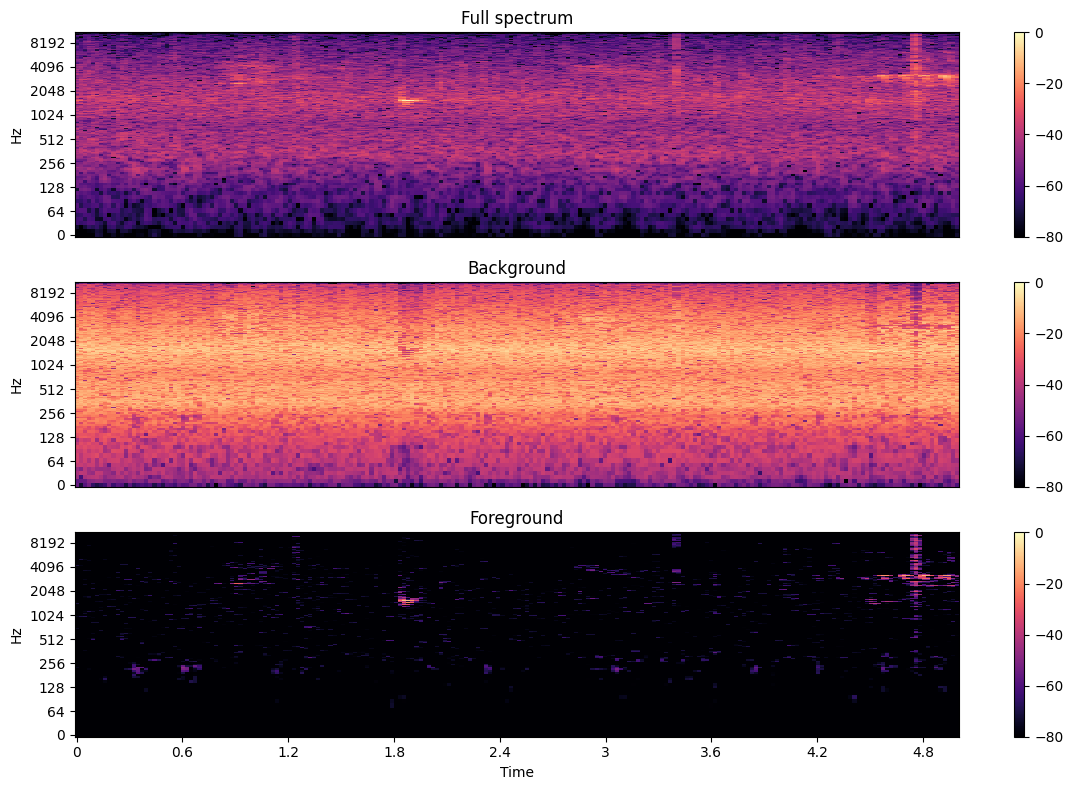

In [17]:
# Code source: Brian McFee
# License: ISC

# sphinx_gallery_thumbnail_number = 2

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
librosa.display.specshow(librosa.amplitude_to_db(S_full[:, idx], ref=np.max),
                         y_axis='log', sr=sr)
plt.title('Full spectrum')
plt.colorbar()

plt.subplot(3, 1, 2)
librosa.display.specshow(librosa.amplitude_to_db(S_background[:, idx], ref=np.max),
                         y_axis='log', sr=sr)
plt.title('Background')
plt.colorbar()
plt.subplot(3, 1, 3)
librosa.display.specshow(librosa.amplitude_to_db(S_foreground[:, idx], ref=np.max),
                         y_axis='log', x_axis='time', sr=sr)
plt.title('Foreground')
plt.colorbar()
plt.tight_layout()
plt.show()

## That below is for wav - No output with ogg

Save it for the next time.

In [18]:
#https://stackoverflow.com/questions/36458214/split-speech-audio-file-on-words-in-python

from pydub import AudioSegment
from pydub.silence import split_on_silence

sound_file = AudioSegment.from_ogg("../input/competitions/birdclef-2026/train_audio/rufgna3/XC252355.ogg")
audio_chunks = split_on_silence(sound_file, 
    # must be silent for at least half a second
    min_silence_len=500,

    # consider it silent if quieter than -16 dBFS
    silence_thresh=-16
)

for i, chunk in enumerate(audio_chunks):

    out_file = ".//splitAudio//chunk{0}.ogg".format(i)
    print ("exporting"), out_file
    chunk.export(out_file, format="ogg")

In [19]:
#Code by Sayantan Mazumdar https://www.kaggle.com/swaralipibose/converting-audio-to-spectogram-noise-image-data/notebook

import tensorflow as tf

2026-03-11 21:51:45.160458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773265905.458211      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773265905.531680      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773265906.219129      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773265906.219166      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773265906.219169      17 computation_placer.cc:177] computation placer alr

In [20]:
#Code by Sayantan Mazumdar https://www.kaggle.com/swaralipibose/converting-audio-to-spectogram-noise-image-data/notebook

!pip install noisereduce

## Chacha1 sample

In [21]:
#Code by Sayantan Mazumdar https://www.kaggle.com/swaralipibose/converting-audio-to-spectogram-noise-image-data/notebook

import IPython
IPython.display.Audio("../input/competitions/birdclef-2026/train_audio/chacha1/XC115879.ogg")

In [22]:
#Code by Sayantan Mazumdar https://www.kaggle.com/swaralipibose/converting-audio-to-spectogram-noise-image-data/notebook

!pip install tensorflow-io

In [23]:
#Code by Sayantan Mazumdar https://www.kaggle.com/swaralipibose/converting-audio-to-spectogram-noise-image-data/notebook

import tensorflow_io as tfio

### Convert Audio to Frequency

In [24]:
import soundfile as sf
freq,rate=sf.read('../input/competitions/birdclef-2026/train_audio/houspa/XC1047601.ogg')

In [25]:
import noisereduce as nr
reduced_noise=nr.reduce_noise(y=freq,sr=rate)

In [26]:
import IPython
IPython.display.Audio("../input/competitions/birdclef-2026/train_audio/yebcar/XC148700.ogg")

## Convert an ogg file to spectogram

What about this spectogram below:

The vertical axis displays frequency in Hertz, the horizontal axis represents time (just like the waveform display), and amplitude is represented by brightness. The darker background is silence?

2026-03-11 21:52:27.647205: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


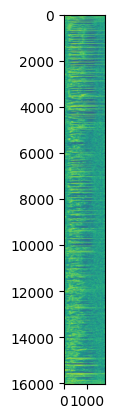

In [27]:
#Code by Sayantan Mazumdar https://www.kaggle.com/swaralipibose/converting-audio-to-spectogram-noise-image-data/notebook

def read(pth,reduce_noise):
    freq,rate=sf.read(pth)
    if reduce_noise:
        freq=nr.reduce_noise(y=freq,sr=rate)
    # Convert to spectrogram
    spectrogram = tfio.audio.spectrogram(
    reduced_noise, nfft=3600, window=256, stride=256)
    return tf.math.log(spectrogram).numpy()
plt.imshow(read('../input/competitions/birdclef-2026/train_audio/yebcar/XC148700.ogg',True));

## Submission (only 235 columns)

sample_submission.csv A valid sample submission.

row_id: A slug of [soundscape_filename]_[end_time] for the prediction; 

e.g., Segment 00:15-00:20 of 1-minute test soundscape

BC2026_Test_0001_S05_20250227_010002.ogg has row ID 

BC2026_Test_0001_S05_20250227_010002_20.

[species_id]: There are 234 species ID columns. You will need to predict the probability of the presence of each species for each row.

In [28]:
sub = pd.read_csv('../input/competitions/birdclef-2026/sample_submission.csv')
sub.tail()

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,22967,22973,22983,22985,23150,23154,23158,23176,23724,24279,24285,24287,24321,244024,25073,25092,25214,326272,41970,43435,47144,47158son01,47158son02,47158son03,47158son04,47158son05,47158son06,47158son07,47158son08,47158son09,47158son10,47158son11,47158son12,47158son13,47158son14,47158son15,47158son16,47158son17,47158son18,47158son19,47158son20,47158son21,47158son22,47158son23,47158son24,47158son25,476521,516975,517063,555123,555145,555146,64898,65377,65380,66971,67107,67252,70711,738183,74113,74580,760266,ashgre1,astcra1,bafcur1,baffal1,banana,barant1,batbel1,baymac,bbwduc,bcwfin2,bkcdon,bkhpar,blchaw1,blheag1,blttit1,bncfly,bobfly1,brcmar1,brnowl,bucmot4,bucpar,bufpar,bunibi1,burowl,camfli1,chacha1,chbmoc1,chobla1,chvcon1,cibspi1,coffal1,compau,compot1,crbthr1,crebec1,dwatin1,epaori4,eulfly1,fabwre1,fepowl,ficman1,flawar1,fotfly,fusfly1,gilhum1,giwrai1,glteme1,grasal3,greani1,greant1,greela,grekis,grepot1,gretho2,greyel,grfdov1,grhtan1,gycwor1,horscr1,houspa,hyamac1,larela1,lesela1,lesgrf1,limpki,linwoo1,litcuc2,litnig1,mabpar,magant1,magtan2,masgna1,nacnig1,ocecra1,oliwoo1,orbtro3,orwpar,osprey,pabspi1,palhor3,paltan1,phecuc1,picpig2,pirfly1,plasla1,platyr1,plcjay1,pluibi1,purjay1,pvttyr1,ragmac1,rebscy1,recfin1,redjun,relser1,rinkin1,rivwar1,roahaw,rubthr1,rufcac2,rufcas2,rufgna3,rufhor2,rufnig1,ruftho1,ruftof1,rumfly1,ruther1,rutjac1,sabspa1,saffin,saytan1,scadov1,schpar1,scther1,shcfly1,shshaw,shtnig1,sibtan2,smbani,smbtin1,sobcac1,sobtyr1,socfly1,sofspi1,souant1,soulap1,souscr1,spbant3,spispi1,sptnig1,squcuc1,stbwoo2,strcuc1,strher2,strowl1,swthum1,swtman1,tattin1,thlwre1,toctou1,trokin,trsowl,undtin1,varant1,watjac1,wesfie1,wfwduc1,whbant2,whbwar2,whiwoo1,whlspi1,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2

#Acknowledgements:

Brian McFee

Paulo Junqueira https://www.kaggle.com/code/paulojunqueira/pew-pew-overview-birdclef-2023/notebook

Ben Jenkins https://www.kaggle.com/code/benjenkins96/identify-eastern-african-bird-species-by-sound

Eunji Goo https://www.kaggle.com/code/quantum09/is-it-going-to-rain

Sayantan Mazumdar https://www.kaggle.com/swaralipibose/converting-audio-to-spectogram-noise-image-data/notebook

Marília Prata https://www.kaggle.com/code/mpwolke/birdclef-2024-western-ghats-species/notebook